# Suturing Quality Scoring - Ordinal Model Training (Ticket 03)

Trains the multi-head ordinal regression model (CORAL): one image in, six
outputs (ISD, Slack, Position, Angulation, Width, Overall), each an ordinal
distribution over 0-10 whose spread is the confidence signal. Model selection
uses a held-out slice of the Train cohort; the official 206-image Val split is
touched only later (ticket 05). CPU run with the `tiny` backbone; the paper
run uses `resnet18` with ImageNet weights on GPU.

In [1]:
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
%matplotlib inline

from suture_scoring.data import SCORE_KEYS, load_annotations
from suture_scoring.dataset import split_annotations
from suture_scoring.train import train_model, evaluate, load_model
from suture_scoring.model import OrdinalSutureModel, OrdinalSutureScorer
from suture_scoring.ordinal import ordinal_probs
from suture_scoring.preprocess import preprocess_image

TRAIN_XLSX = ROOT / "Dataset/Train/Train_cohort/Train_annotations.xlsx"
TRAIN_IMAGES = ROOT / "Dataset/Train/Train_cohort/Train"
CHECKPOINT = ROOT / "models/tiny-cpu.pt"

In [2]:
annotations = load_annotations(TRAIN_XLSX)
train_anns, val_anns = split_annotations(annotations, frac=0.12, seed=0)
print(f"{len(train_anns)} train / {len(val_anns)} held-out validation images")

889 train / 121 held-out validation images


In [3]:
# Quick self-contained run: first 300 images, 4 epochs, tiny backbone
subset = train_anns[:300]
history, best_mae = train_model(
    TRAIN_IMAGES, subset, val_anns,
    epochs=4, batch_size=16, size=96, backbone="tiny", embedding=64,
    seed=0, verbose=False,
)
print(f"best held-out Overall MAE (subset run): {best_mae:.3f}")

best held-out Overall MAE (subset run): 1.099


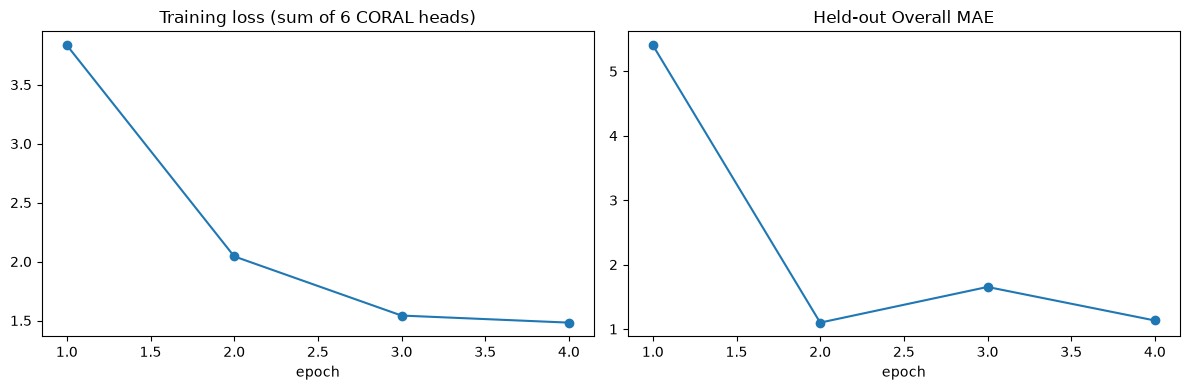

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], "o-")
axes[0].set_title("Training loss (sum of 6 CORAL heads)")
axes[0].set_xlabel("epoch")
axes[1].plot(
    sorted(history["val"]),
    [history["val"][e]["Overall"]["mae"] for e in sorted(history["val"])],
    "o-",
)
axes[1].set_title("Held-out Overall MAE")
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [5]:
final = history["val"][max(history["val"])]
pd.DataFrame(final).T.round(3)

,mae,exact,tol1,spearman,ece
Overall,1.132,0.248,0.702,NaN,0.032
ISD,0.868,0.322,0.835,-0.015,0.039
Slack,1.248,0.256,0.719,NaN,0.028
Position,1.000,0.298,0.818,NaN,0.022
Angulation,1.050,0.281,0.727,-0.025,0.057
Width,0.702,0.463,0.860,NaN,0.030


In [6]:
# Load the full-cohort CLI checkpoint and score a fixture image
model = load_model(CHECKPOINT)
scorer = OrdinalSutureScorer(model)
image = preprocess_image(ROOT / "tests/fixtures/images/Image_0000_04_0_0_4.png", size=224)
row = {"filename": "Image_0000_04_0_0_4.png", **scorer.score(image)}
pd.DataFrame([row]).T

,0
filename,Image_0000_04_0_0_4.png
Overall,6.0
conf_Overall,0.415421
ISD,6.0
conf_ISD,0.47433
Slack,6.0
conf_Slack,0.416705
Position,6.0
conf_Position,0.470411
Angulation,6.0


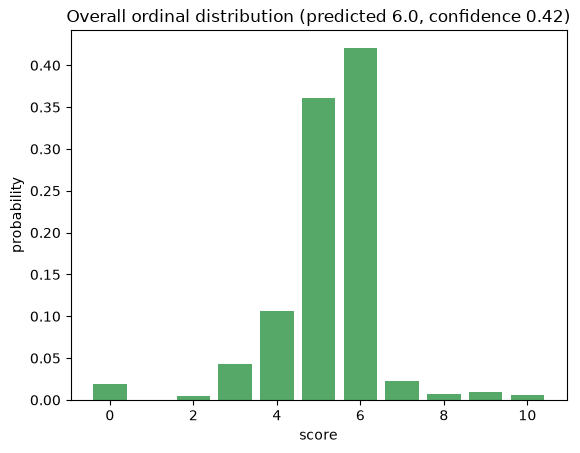

In [7]:
# The ordinal distribution behind the Overall prediction (spread = confidence)
tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0)
with torch.no_grad():
    probs = ordinal_probs(model(tensor)["Overall"][0]).numpy()
plt.bar(range(11), probs, color="#55A868")
plt.title(f"Overall ordinal distribution (predicted {row['Overall']}, confidence {row['conf_Overall']:.2f})")
plt.xlabel("score")
plt.ylabel("probability")
plt.show()

## Next steps

- **Paper run**: `resnet18` with ImageNet weights (`pretrained=True`), GPU,
  more epochs, input 224+ — the `tiny` backbone and 96-128px inputs here are
  CPU development choices, not the paper configuration.
- **Ticket 04**: hybrid `Overall` aggregation over the five predicted
  parameters + learned residual (ADR-0001).
- **Ticket 05**: score all three cohorts with the trained model; validate
  against expert labels (ICC, weighted kappa per trainee level).